In [ ]:
import RF_Track as rft
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

from aux import plot_phase_space, plot_lattice
from data import parser
from structure import create_lebt

%load_ext autoreload
%autoreload 2


RF-Track, version 2.5.5

Copyright (C) 2016-2025 CERN, Geneva, Switzerland. All rights reserved.

Author and contact:
 Andrea Latina <andrea.latina@cern.ch>
 BE-ABP Group
 CERN
 CH-1211 GENEVA 23
 SWITZERLAND

This software is distributed under a CERN proprietary software
license in the hope that it will be useful, but WITHOUT ANY WARRANTY;
not even for MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.

See the COPYRIGHT and LICENSE files at the top-level directory of
the RF-Track download area: https://gitlab.cern.ch/rf-track

RF-Track was compiled with GSL-2.5 and fftw-3.3.5-sse2-avx



[RF-Track] Could not check for updates.


### Initial Bunch

In [2]:
B0 = parser()
M0 = B0.get_phase_space('%x %xp %y %yp %N')

x  = M0[:,0]
xp = M0[:,1]
y  = M0[:,2]
yp = M0[:,3]
No = M0[:,4]


#plot_phase_space(x, xp, "x [mm]", "x' [rad]")
#plot_phase_space(y, yp, "y [mm]", "y' [rad]")
#plot_phase_space(x, y,  "x [mm]", "y [mm]")



N: 15673, Mass: 11174.9 MeV, Energy: 0.182629 MeV, Frequency: 749.48 MHz, Current: 2.89e-06 A, Charge: 1 e


### LEBT

K1_dip: 0.0 1/m^2, Bfield_dip: 0.5327742176359231 T
B:0.5327742176359231 T

X-X'
emit = 0.1230093379697872 mm·mrad
beta = 30.378061836755233 mm/mrad
alpha = -19.121173853376852

Y-Y'
emit = 0.09509125820154064 mm·mrad
beta = 28.573562881206826 mm/mrad
alpha = -22.162990599004544

4D
emit4D = 0.0005562741783871356 (mm·mrad)^2


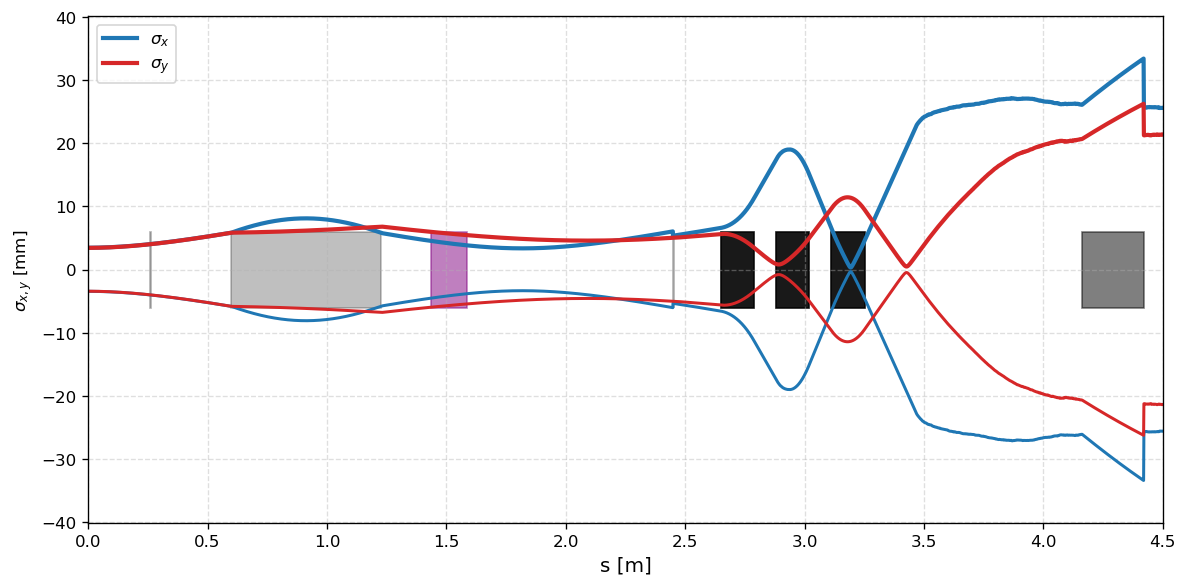

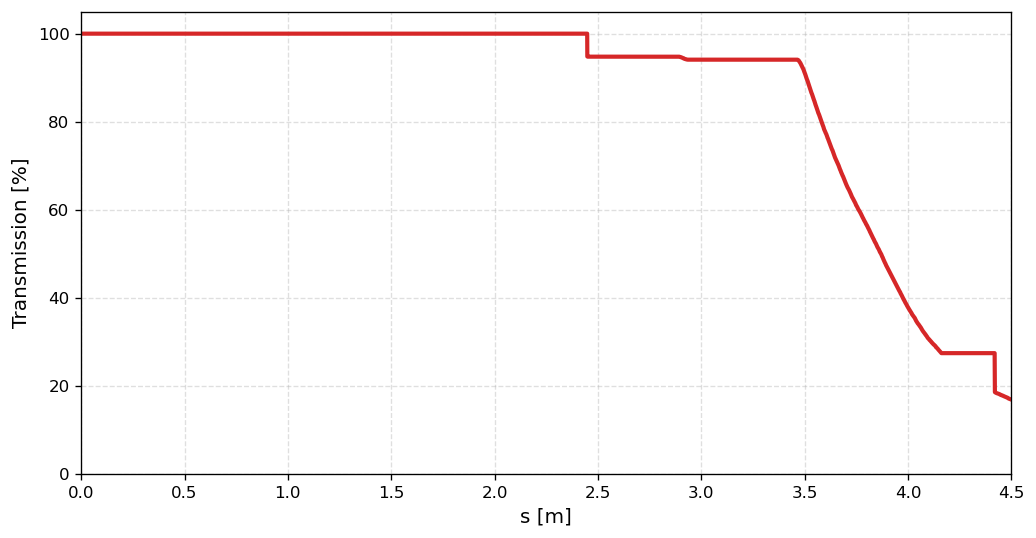

In [3]:
lebt = create_lebt(B0)

B1 = lebt.track(B0)
I = B1.get_info()
    

print("\nX-X'")
print("emit =", I.emitt_x, "mm·mrad")
print("beta =", I.beta_x, "mm/mrad")
print("alpha =", I.alpha_x)

print("\nY-Y'")
print("emit =", I.emitt_y, "mm·mrad")
print("beta =", I.beta_y, "mm/mrad")
print("alpha =", I.alpha_y)

print("\n4D")
print("emit4D =", I.emitt_4d**2, "(mm·mrad)^2")


M1 = B1.get_phase_space('%x %xp %y %yp %N')

x  = M1[:,0]
xp = M1[:,1]
y  = M1[:,2]
yp = M1[:,3]

#plot_phase_space(x, xp, "x [mm]", "x' [rad]")
#plot_phase_space(y,yp,"y [mm]", "y' [rad]")
#plot_phase_space(x, y,  "x [mm]", "y [mm]")


T = lebt.get_transport_table('%S %sigma_x %sigma_y %N')

s  = T[:, 0]
mx = T[:, 1]
my = T[:, 2]
N  = T[:, 3]

# Plot rms 
fig, ax = plt.subplots(figsize=(10, 5), dpi=120)
color_x = 'tab:blue'
color_y = 'tab:red'
ax.plot(s,  mx,  color=color_x, linewidth=2.5, linestyle='-',  label=r'$\sigma_x$')
ax.plot(s, -mx,  color=color_x, linewidth=1.8, linestyle='-')
ax.plot(s,  my,  color=color_y, linewidth=2.5, linestyle='-',  label=r'$\sigma_y$')
ax.plot(s, -my,  color=color_y, linewidth=1.8, linestyle='-')
ax.set_xlabel('s [m]', fontsize=12)
ax.set_ylabel(r'$\sigma_{x,y}$ [mm]')

ax.set_xlim(0, 4.5)
ax.set_ylim(-max(mx)*1.2, max(mx)*1.2)

ax.legend(loc='upper left') 
ax.grid(True, linestyle='--', alpha=0.4)

plot_lattice(ax)

plt.tight_layout()
plt.show()

#Plot transmission

plt.figure(figsize=(10, 5), dpi=120)
plt.plot(s, N/N[0]*100, color='tab:red', linewidth=2.5, linestyle='-', label='Transmission')
plt.xlabel('s [m]', fontsize=12)
plt.ylabel('Transmission [%]', fontsize=12)
plt.xlim(0, 4.5) 
plt.ylim(0, 105)
plt.grid(True, linestyle='--', alpha=0.4)

